In [1]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load all CSV files
customers = pd.read_csv('../data/olist_customers_dataset.csv')
orders = pd.read_csv('../data/olist_orders_dataset.csv')
order_items = pd.read_csv('../data/olist_order_items_dataset.csv')
payments = pd.read_csv('../data/olist_order_payments_dataset.csv')
reviews = pd.read_csv('../data/olist_order_reviews_dataset.csv')
products = pd.read_csv('../data/olist_products_dataset.csv')
sellers = pd.read_csv('../data/olist_sellers_dataset.csv')
category_translation = pd.read_csv('../data/product_category_name_translation.csv')

print("All files loaded successfully")
print(f"Orders: {orders.shape}")
print(f"Customers: {customers.shape}")
print(f"Order Items: {order_items.shape}")

All files loaded successfully
Orders: (99441, 8)
Customers: (99441, 5)
Order Items: (112650, 7)


In [3]:
# Create SQLite database
conn = sqlite3.connect('../data/olist.db')

# Save all dataframes as SQL tables
customers.to_sql('customers', conn, if_exists='replace', index=False)
orders.to_sql('orders', conn, if_exists='replace', index=False)
order_items.to_sql('order_items', conn, if_exists='replace', index=False)
payments.to_sql('payments', conn, if_exists='replace', index=False)
reviews.to_sql('reviews', conn, if_exists='replace', index=False)
products.to_sql('products', conn, if_exists='replace', index=False)
sellers.to_sql('sellers', conn, if_exists='replace', index=False)
category_translation.to_sql('category_translation', conn, if_exists='replace', index=False)

print("Database created successfully!")

Database created successfully!


     month  total_revenue  total_orders
0  2016-10       46566.71           265
1  2016-12          19.62             1
2  2017-01      127545.67           750
3  2017-02      271298.65          1653
4  2017-03      414369.39          2546
5  2017-04      390952.18          2303
6  2017-05      567066.73          3546
7  2017-06      490225.60          3135
8  2017-07      566403.93          3872
9  2017-08      646000.61          4193


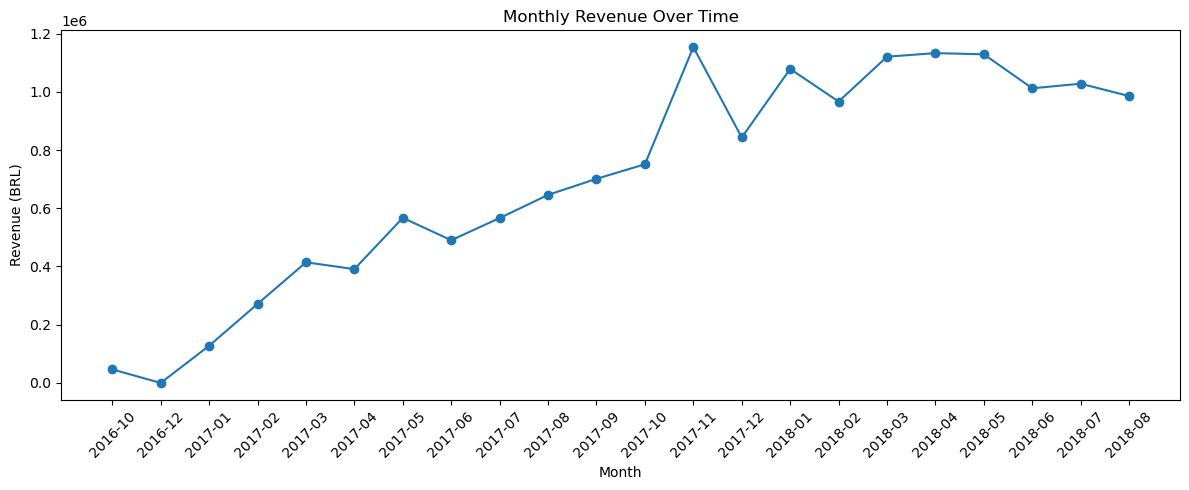

In [4]:
query1 = """
SELECT 
    strftime('%Y-%m', o.order_purchase_timestamp) AS month,
    ROUND(SUM(p.payment_value), 2) AS total_revenue,
    COUNT(DISTINCT o.order_id) AS total_orders
FROM orders o
JOIN payments p ON o.order_id = p.order_id
WHERE o.order_status = 'delivered'
GROUP BY month
ORDER BY month
"""

revenue_by_month = pd.read_sql_query(query1, conn)
print(revenue_by_month.head(10))

# Plot
plt.figure(figsize=(12, 5))
plt.plot(revenue_by_month['month'], revenue_by_month['total_revenue'], marker='o')
plt.xticks(rotation=45)
plt.title('Monthly Revenue Over Time')
plt.xlabel('Month')
plt.ylabel('Revenue (BRL)')
plt.tight_layout()
plt.show()

                category  total_revenue  total_orders
0          health_beauty     1258681.34          9670
1          watches_gifts     1205005.68          5991
2         bed_bath_table     1036988.68         11115
3         sports_leisure      988048.97          8641
4  computers_accessories      911954.32          7827
5        furniture_decor      729762.49          8334
6             cool_stuff      635290.85          3796
7             housewares      632248.66          6964
8                   auto      592720.11          4235
9           garden_tools      485256.46          4347


C:\Users\WELCOME\AppData\Local\Temp\ipykernel_10228\2776751221.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_categories, x='total_revenue', y='category', palette='viridis')


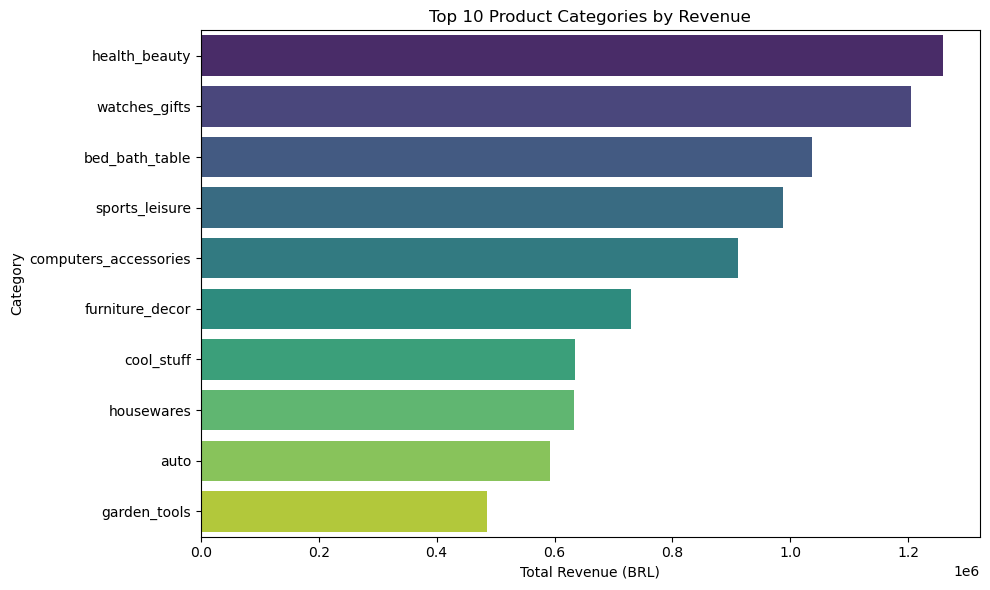

In [5]:
query2 = """
SELECT 
    ct.product_category_name_english AS category,
    ROUND(SUM(oi.price), 2) AS total_revenue,
    COUNT(oi.order_id) AS total_orders
FROM order_items oi
JOIN products p ON oi.product_id = p.product_id
JOIN category_translation ct ON p.product_category_name = ct.product_category_name
GROUP BY category
ORDER BY total_revenue DESC
LIMIT 10
"""

top_categories = pd.read_sql_query(query2, conn)
print(top_categories)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(data=top_categories, x='total_revenue', y='category', palette='viridis')
plt.title('Top 10 Product Categories by Revenue')
plt.xlabel('Total Revenue (BRL)')
plt.ylabel('Category')
plt.tight_layout()
plt.show()

  state  total_customers  total_spent
0    SP            41745   5998226.96
1    RJ            12852   2144379.69
2    MG            11635   1872257.26
3    RS             5466    890898.54
4    PR             5045    811156.38
5    SC             3637    623086.43
6    BA             3380    616645.82
7    DF             2140    355141.08
8    ES             2033    325967.55
9    GO             2020    350092.31


C:\Users\WELCOME\AppData\Local\Temp\ipykernel_10228\2135083642.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=customers_by_state, x='total_customers', y='state', palette='Blues_r')


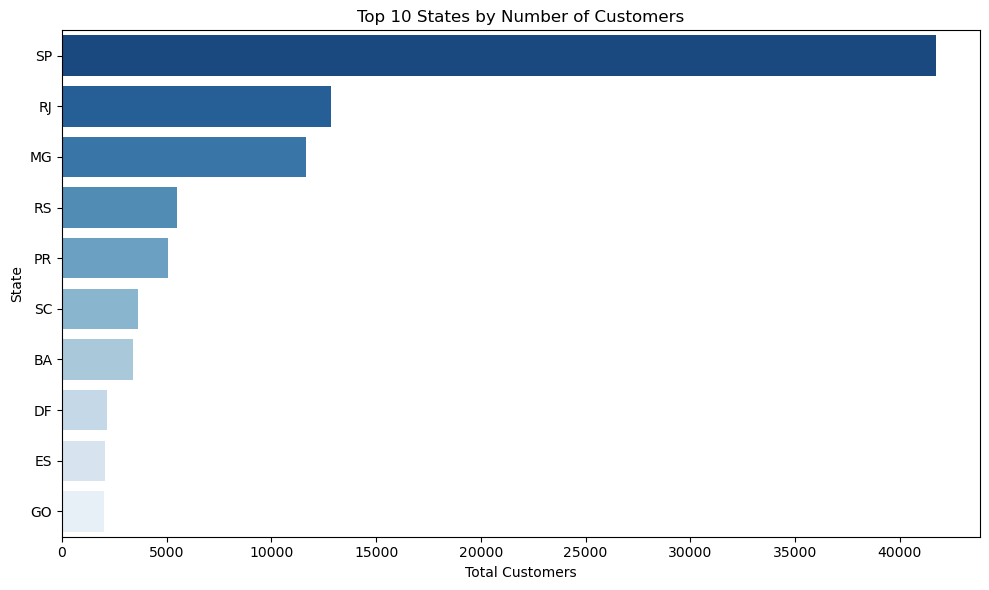

In [6]:
query3 = """
SELECT 
    c.customer_state AS state,
    COUNT(DISTINCT o.customer_id) AS total_customers,
    ROUND(SUM(p.payment_value), 2) AS total_spent
FROM customers c
JOIN orders o ON c.customer_id = o.customer_id
JOIN payments p ON o.order_id = p.order_id
GROUP BY state
ORDER BY total_customers DESC
LIMIT 10
"""

customers_by_state = pd.read_sql_query(query3, conn)
print(customers_by_state)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(data=customers_by_state, x='total_customers', y='state', palette='Blues_r')
plt.title('Top 10 States by Number of Customers')
plt.xlabel('Total Customers')
plt.ylabel('State')
plt.tight_layout()
plt.show()

                 category  avg_review_score  total_reviews
0  books_general_interest              4.45            549
1         books_technical              4.37            266
2     luggage_accessories              4.32           1088
3              food_drink              4.32            279
4           fashion_shoes              4.23            261
5                    food              4.22            495
6              stationery              4.19           2507
7                pet_shop              4.19           1939
8         home_appliances              4.17            806
9               computers              4.17            200


C:\Users\WELCOME\AppData\Local\Temp\ipykernel_10228\960901294.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=reviews_by_category, x='avg_review_score', y='category', palette='RdYlGn')


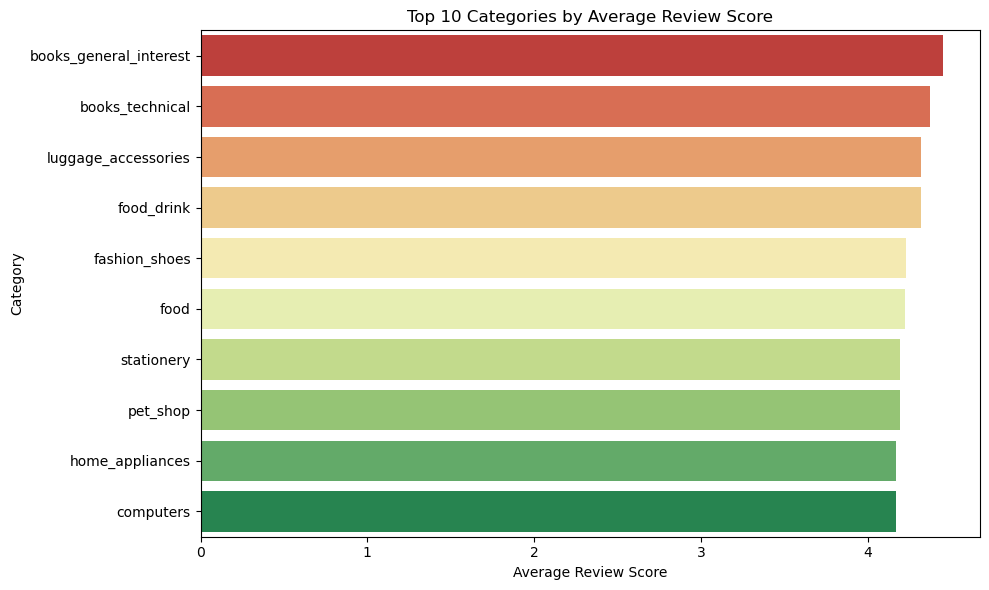

Analysis complete!


In [7]:
query4 = """
SELECT 
    ct.product_category_name_english AS category,
    ROUND(AVG(r.review_score), 2) AS avg_review_score,
    COUNT(r.review_id) AS total_reviews
FROM reviews r
JOIN orders o ON r.order_id = o.order_id
JOIN order_items oi ON o.order_id = oi.order_id
JOIN products p ON oi.product_id = p.product_id
JOIN category_translation ct ON p.product_category_name = ct.product_category_name
GROUP BY category
HAVING total_reviews > 100
ORDER BY avg_review_score DESC
LIMIT 10
"""

reviews_by_category = pd.read_sql_query(query4, conn)
print(reviews_by_category)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(data=reviews_by_category, x='avg_review_score', y='category', palette='RdYlGn')
plt.title('Top 10 Categories by Average Review Score')
plt.xlabel('Average Review Score')
plt.ylabel('Category')
plt.tight_layout()
plt.show()

conn.close()
print("Analysis complete!")